# 🔍 Model Explainability (SHAP)
**Project ResistAI**

In clinical settings, doctors cannot trust a "black box" algorithm. They need to know *why* the model made a specific prediction. 

We use **SHAP (SHapley Additive exPlanations)** to break down our predictions:
1. **Global Explainability:** Which biological features drive resistance across all bacteria?
2. **Local Explainability:** Why did the model predict resistance for *this specific patient's* isolate?

In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Keep visuals clean
warnings.filterwarnings('ignore')

In [3]:
# 1. Load the model and dataset
print("Loading model and data...")
model = joblib.load("../models/xgb_model.pkl")
df = pd.read_csv("../data/processed/final_dataset.csv")

feature_cols = [
    'species_enc', 'antibiotic_enc', 'isolation_source_enc', 
    'mic_value', 'multi_drug_count', 'gram_stain_enc'
]

X = df[feature_cols]

# SHAP can be computationally heavy, so we take a representative sample of 1,000 isolates to build our global summary
X_sample = shap.sample(X, 1000, random_state=42)
print("Data ready for SHAP analysis.")

Loading model and data...
Data ready for SHAP analysis.


Calculating SHAP values... (This takes a few seconds)


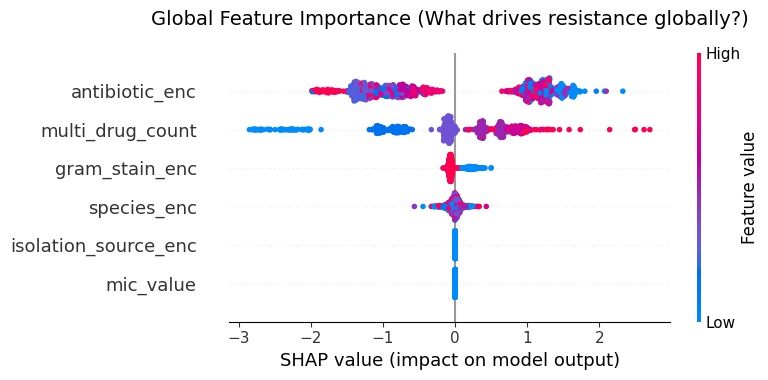

Interpretation: Features at the top are the most important. Red dots pushing to the right mean high values of that feature increase the probability of Resistance.


In [4]:
# 2. Generate Global Explainability
print("Calculating SHAP values... (This takes a few seconds)")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

# Plot the Beeswarm Summary
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("Global Feature Importance (What drives resistance globally?)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Interpretation: Features at the top are the most important. Red dots pushing to the right mean high values of that feature increase the probability of Resistance.")

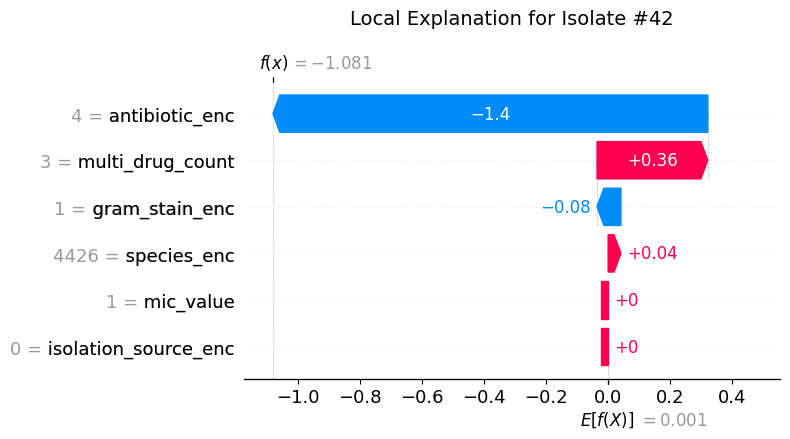

Interpretation: This chart shows exactly how each clinical feature pushed the model's final prediction either towards Susceptible (blue) or Resistant (red).


In [5]:
# 3. Generate Local Explainability (Simulating a single patient)
# Let's pick a random resistant isolate from our sample
isolate_index = 42 

plt.figure(figsize=(8, 4))
shap.plots.waterfall(shap_values[isolate_index], show=False)
plt.title(f"Local Explanation for Isolate #{isolate_index}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Interpretation: This chart shows exactly how each clinical feature pushed the model's final prediction either towards Susceptible (blue) or Resistant (red).")